# Peering Inside BLIP-2's Q-Former

### How many of the 32 learned visual queries are actually doing anything?

BLIP-2 connects a frozen vision encoder to a frozen language model through a small
trainable bridge, the Q-Former, which compresses each image down to 32 learned query
vectors before anything reaches the language model. That's a real information
bottleneck by design, and it raises an obvious question the original paper never
directly answers: **is the full 32-query bottleneck actually necessary, or is a lot of
it dead weight?**

This notebook investigates that question on the public `Salesforce/blip2-itm-vit-g`
checkpoint, in four stages, each building on the last:

1. **Experiment A -- Representation Probing.** Does compressing 257 raw ViT patch
   features into 32 Q-Former queries lose linearly-accessible semantic information, or
   just reorganize it?
2. **Experiment B -- Query Specialization.** Are the 32 queries doing genuinely
   different jobs, or mostly duplicating each other? Which ones are actually "dead"?
3. **Experiment C -- Query Ablation.** How many of the 32 queries can be thrown away
   before image-text retrieval performance actually drops, and does *which* queries
   you keep matter more than *how many*?
4. **Experiment D -- From Ablation to Generation.** Experiments A-C never leave the
   world of similarity scores. Does the same "a handful of queries carry almost
   everything" finding survive once a real frozen LLM has to turn those queries into
   free-form text?

All of Experiments A-C run on a class-balanced subset of COCO val2017 (1,599 images
across 12 COCO supercategories, capped at 150 images per category so the results
aren't just measuring "can you detect a person").


In [1]:
!pip install -q transformers accelerate pillow httpx scikit-learn umap-learn matplotlib

## Setup

We use `Salesforce/blip2-itm-vit-g` -- the BLIP-2 checkpoint Salesforce fine-tuned
specifically for image-text matching/retrieval. It exposes the vision side
(frozen ViT-g + Q-Former + projection head) and the text side (text transformer +
projection head) as two separate models with no language model attached, which is
exactly the surface area Experiments A-C need. Experiment D later swaps in the
full generative checkpoint (`blip2-opt-2.7b`) once we actually need captions
instead of similarity scores.


In [2]:
import torch
from transformers import AutoProcessor, Blip2VisionModelWithProjection, Blip2TextModelWithProjection

device = "cuda" if torch.cuda.is_available() else "cpu"
checkpoint = "Salesforce/blip2-itm-vit-g"

processor = AutoProcessor.from_pretrained(checkpoint)
vision_model = Blip2VisionModelWithProjection.from_pretrained(checkpoint, dtype=torch.float16, attn_implementation="eager").to(device)
text_model = Blip2TextModelWithProjection.from_pretrained(checkpoint, dtype=torch.float16, attn_implementation="eager").to(device)

vision_model.eval()
text_model.eval()

preprocessor_config.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/554 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.51k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/21.0 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/803 [00:00<?, ?it/s]

[transformers] Blip2VisionModelWithProjection LOAD REPORT from: Salesforce/blip2-itm-vit-g
Key                                   | Status     |  | 
--------------------------------------+------------+--+-
text_projection.weight                | UNEXPECTED |  | 
embeddings.position_embeddings.weight | UNEXPECTED |  | 
embeddings.word_embeddings.weight     | UNEXPECTED |  | 
text_projection.bias                  | UNEXPECTED |  | 
itm_head.weight                       | UNEXPECTED |  | 
itm_head.bias                         | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/331 [00:00<?, ?it/s]

[transformers] Blip2TextModelWithProjection LOAD REPORT from: Salesforce/blip2-itm-vit-g
Key                                                              | Status     |  | 
-----------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...38}.mlp.fc2.weight              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...38}.layer_norm1.bias            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...38}.layer_norm2.weight          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...38}.layer_norm2.bias            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...38}.self_attn.projection.bias   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...38}.mlp.fc1.weight              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...38}.layer_norm1.weight          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...38}.self_attn.qkv.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...38}.self_attn.qkv.bias          | UNEX

Blip2TextModelWithProjection(
  (embeddings): Blip2TextEmbeddings(
    (word_embeddings): Embedding(30523, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
  )
  (qformer): Blip2QFormerModel(
    (layernorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (encoder): Blip2QFormerEncoder(
      (layer): ModuleList(
        (0): Blip2QFormerLayer(
          (attention): Blip2QFormerAttention(
            (attention): Blip2QFormerMultiHeadAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): Blip2QFormerSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
              (dropout): Dropout(

In [3]:
import torch.nn.functional as F
from PIL import Image
import httpx
from io import BytesIO

# load sample image
url = "http://images.cocodataset.org/val2017/000000039769.jpg"
with httpx.stream("GET", url) as response:
    image = Image.open(BytesIO(response.read())).convert("RGB")

# preprocess image and text
vision_inputs = processor(images=image, return_tensors="pt").to(device, torch.float16)  # resizes + normalizes + patchifies the image (see the ViT paper for the patch-embedding step)
text_inputs = processor(text=["two cats laying on a couch"], return_tensors="pt").to(device)  # tokenizes the caption into input_ids, same idea as a BERT tokenizer

with torch.inference_mode():

    # normal forward pass through the vision and text models
    vision_out = vision_model(**vision_inputs, output_attentions=True)  # image embedding acquired
    text_out = text_model(**text_inputs)  # text embedding acquired

    # get the ViT patch features

    # patch_embeds shape is (1, 257, 1408): 256 image patches + 1 [CLS] token, each a 1408-dim vector (ViT-g's hidden size)
    patch_embeds = vision_model.vision_model(
        pixel_values=vision_inputs.pixel_values
    ).last_hidden_state  # accessing the ViT submodule directly to get the raw patch features

    # get the 32 learned query tokens
    query_tokens = vision_model.query_tokens.expand(
        patch_embeds.shape[0], -1, -1
    )
    # query_tokens starts as a (32, 768) parameter; expand() adds the batch dimension -> (1, 32, 768) here, since we passed a single image

    # run the queries through the Q-Former: self-attention among the 32 queries,
    # interleaved with cross-attention where the queries read the frozen ViT features
    qformer_out = vision_model.qformer(
        query_embeds=query_tokens,
        encoder_hidden_states=patch_embeds,
        output_attentions=True,
    )

    # output of the 32 queries after attending to the image
    qformer_hidden = qformer_out.last_hidden_state

    # project Q-Former features (768-d) down into BLIP-2's shared image-text embedding space (256-d)
    projected = vision_model.vision_projection(
        qformer_hidden.to(vision_model.vision_projection.weight.dtype)
    )

# compare our manual computation with the model's normal output
print("forward() image_embeds", vision_out.image_embeds.shape)
print("manual qformer_hidden", qformer_hidden.shape, qformer_hidden.dtype)
print("manual projected", projected.shape)

# check if our manually computed output matches the model output
print("matches raw", torch.allclose(projected, vision_out.image_embeds, atol=1e-3))

# also check after normalization
print(
    "matches normalized",
    torch.allclose(
        F.normalize(projected, dim=-1),
        vision_out.image_embeds,
        atol=1e-3
    )
)

# see how different the two outputs actually are
print(
    "max abs diff raw",
    (projected - vision_out.image_embeds).abs().max().item()
)

print(
    "max abs diff normalized",
    (F.normalize(projected, dim=-1) - vision_out.image_embeds)
    .abs().max().item()
)


forward() image_embeds torch.Size([1, 32, 256])
manual qformer_hidden torch.Size([1, 32, 768]) torch.float32
manual projected torch.Size([1, 32, 256])
matches raw False
matches normalized True
max abs diff raw 1.5224609375
max abs diff normalized 0.0



## Experiment A — Representation Probing

**Question:** does the Q-Former's 32-query output carry more linearly-accessible semantic information
than the raw frozen ViT patch features it's built from?

In [4]:
!wget -q http://images.cocodataset.org/zips/val2017.zip
!wget -q http://images.cocodataset.org/annotations/annotations_trainval2017.zip
!unzip -q val2017.zip
!unzip -q annotations_trainval2017.zip
!pip install -q pycocotools

In [5]:
import random
from collections import Counter
from pycocotools.coco import COCO
# COCO doesn't hand us one label per image -- it hands us a list of object
# annotations. We assign each image the supercategory that covers the most pixel
# area, so we end up with a single, clean multi-class label per image to probe.
coco = COCO("annotations/instances_val2017.json")
cat_id_to_supercat = {c["id"]: c["supercategory"] for c in coco.loadCats(coco.getCatIds())}

records = []
for img_id in coco.getImgIds():
    anns = coco.loadAnns(coco.getAnnIds(imgIds=img_id))
    if not anns:
        continue
    area_by_supercat = {}
    for ann in anns:
        supercat = cat_id_to_supercat[ann["category_id"]]
        area_by_supercat[supercat] = area_by_supercat.get(supercat, 0) + ann["area"]
    dominant_supercat = max(area_by_supercat, key=area_by_supercat.get)
    file_name = coco.loadImgs(img_id)[0]["file_name"]
    records.append({"image_id": img_id, "file_name": file_name, "label": dominant_supercat})

print(len(records))
print(Counter(r["label"] for r in records))

random.seed(0)
by_label = {}
for r in records:
    by_label.setdefault(r["label"], []).append(r)
# COCO val2017 is heavily skewed toward "person" -- capping each supercategory at
# 150 images keeps the probing experiments from just measuring "can you detect a person."
cap = 150
subset = []
for label, items in by_label.items():
    random.shuffle(items)
    subset.extend(items[:cap])

random.shuffle(subset)
print(len(subset))
print(Counter(r["label"] for r in subset))


loading annotations into memory...
Done (t=3.63s)
creating index...
index created!
4952
Counter({'person': 1608, 'vehicle': 773, 'animal': 708, 'furniture': 614, 'food': 252, 'outdoor': 219, 'indoor': 204, 'appliance': 175, 'electronic': 148, 'kitchen': 98, 'accessory': 81, 'sports': 72})
1599
Counter({'person': 150, 'indoor': 150, 'food': 150, 'appliance': 150, 'vehicle': 150, 'animal': 150, 'furniture': 150, 'outdoor': 150, 'electronic': 148, 'kitchen': 98, 'accessory': 81, 'sports': 72})


In [6]:
import os
import torch
import numpy as np
from PIL import Image
from tqdm.auto import tqdm
# Extract two representations per image: the raw ViT patch features (mean-pooled
# over the 256 patches, excluding the [CLS] token) and the Q-Former output
# (mean-pooled over the 32 queries). Same forward pass, two pooled summaries to compare.
image_dir = "val2017"
batch_size = 16

all_vit_pooled = []
all_qformer_pooled = []
all_labels = []

for i in tqdm(range(0, len(subset), batch_size)):
    batch = subset[i:i + batch_size]
    images = [Image.open(os.path.join(image_dir, r["file_name"])).convert("RGB") for r in batch]
    inputs = processor(images=images, return_tensors="pt").to(device, torch.float16)

    with torch.inference_mode():
        patch_embeds = vision_model.vision_model(pixel_values=inputs.pixel_values).last_hidden_state
        query_tokens = vision_model.query_tokens.expand(patch_embeds.shape[0], -1, -1)
        qformer_out = vision_model.qformer(query_embeds=query_tokens, encoder_hidden_states=patch_embeds)
        qformer_hidden = qformer_out.last_hidden_state

    vit_pooled = patch_embeds[:, 1:, :].mean(dim=1)
    qformer_pooled = qformer_hidden.mean(dim=1)

    all_vit_pooled.append(vit_pooled.float().cpu())
    all_qformer_pooled.append(qformer_pooled.float().cpu())
    all_labels.extend([r["label"] for r in batch])

vit_pooled = torch.cat(all_vit_pooled).numpy()
qformer_pooled = torch.cat(all_qformer_pooled).numpy()
labels = np.array(all_labels)

np.save("vit_pooled.npy", vit_pooled)
np.save("qformer_pooled.npy", qformer_pooled)
np.save("labels.npy", labels)

print(vit_pooled.shape, qformer_pooled.shape, labels.shape)


  0%|          | 0/100 [00:00<?, ?it/s]

(1599, 1408) (1599, 768) (1599,)


In [7]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score
# Two probes, two different questions about the geometry of each representation:
#   - logistic regression: is the class information linearly separable at all?
#   - k-NN: do same-class points end up near each other, even without a linear boundary?
# Comparing ViT vs. Q-Former on both tells us whether the 32-query bottleneck is
# throwing signal away, or just rearranging it into a different (more local) geometry.
le = LabelEncoder()
y = le.fit_transform(labels)


def cv_scores(X, y, n_splits=5):
    """5-fold stratified CV accuracy for a standardized logistic-regression probe.
    Reused later (Experiment B) to score each of the 32 queries individually."""
    skf_local = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=0)
    pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
    scores = cross_val_score(pipe, X, y, cv=skf_local)
    return scores, scores.mean()


def evaluate(X, y, name):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    clf = LogisticRegression(max_iter=2000)
    clf.fit(X_train, y_train)
    probe_acc = accuracy_score(y_test, clf.predict(X_test))

    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train, y_train)
    knn_acc = accuracy_score(y_test, knn.predict(X_test))

    print(f"{name}: logistic regression acc = {probe_acc:.3f}, k-NN acc = {knn_acc:.3f}")
    return probe_acc, knn_acc


vit_results = evaluate(vit_pooled, y, "Raw ViT (mean-pooled patches)")
qformer_results = evaluate(qformer_pooled, y, "Q-Former (mean-pooled queries)")


Raw ViT (mean-pooled patches): logistic regression acc = 0.766, k-NN acc = 0.691
Q-Former (mean-pooled queries): logistic regression acc = 0.762, k-NN acc = 0.762


## Experiment B — Query Specialization

**Question:** are the Q-Former's 32 queries doing distinct jobs, or largely duplicating each other?

Given Experiment A's finding — the Q-Former's *pooled* output has better nearest-neighbor class
structure than raw ViT features, without more raw linear-separable information — the natural next
question is where that structure comes from: is it distributed evenly across all 32 queries, or
concentrated in a handful of them?

Four analyses, using the full per-query (32, 768) Q-Former state and the Q-Former's cross-attention
over image patches (averaged across the 6 cross-attention layers and 12 heads):

1. **Redundancy** — average pairwise cosine similarity between all 32 queries, within each image,
   averaged across the dataset. High off-diagonal similarity = queries carrying near-duplicate content.
2. **Attention entropy** — how spatially focused vs. diffuse each query's attention over the image is,
   averaged per query index across the dataset.
3. **Attention heatmaps** — qualitative: visualize where a handful of representative queries look on
   example images.
4. **Per-query probe importance** — train a separate linear probe on *each* query's 768-d vector alone
   (not pooled) and rank the 32 queries by standalone classification accuracy. This ranking is what
   Experiment C's informed pruning will use.

In [8]:
import torch
import numpy as np
from PIL import Image
from tqdm.auto import tqdm
import os

image_dir = "val2017"
batch_size = 16

all_qformer_full = []
all_attn_maps = []
all_labels_b = []

for i in tqdm(range(0, len(subset), batch_size)):
    batch = subset[i:i + batch_size]
    images = [Image.open(os.path.join(image_dir, r["file_name"])).convert("RGB") for r in batch]
    inputs = processor(images=images, return_tensors="pt").to(device, torch.float16)

    with torch.inference_mode():
        patch_embeds = vision_model.vision_model(pixel_values=inputs.pixel_values).last_hidden_state
        query_tokens = vision_model.query_tokens.expand(patch_embeds.shape[0], -1, -1)
        qformer_out = vision_model.qformer(
            query_embeds=query_tokens,
            encoder_hidden_states=patch_embeds,
            output_attentions=True,
        )
        qformer_hidden = qformer_out.last_hidden_state
        cross_attentions = qformer_out.cross_attentions

    stacked_attn = torch.stack([ca for ca in cross_attentions if ca is not None], dim=0)
    mean_attn = stacked_attn.mean(dim=(0, 2))

    all_qformer_full.append(qformer_hidden.float().cpu())
    all_attn_maps.append(mean_attn.float().cpu())
    all_labels_b.extend([r["label"] for r in batch])

qformer_full = torch.cat(all_qformer_full).numpy()
attn_maps = torch.cat(all_attn_maps).numpy()
labels_b = np.array(all_labels_b)

np.save("qformer_full.npy", qformer_full)
np.save("attn_maps.npy", attn_maps)
np.save("labels_b.npy", labels_b)

print("qformer_full", qformer_full.shape)
print("attn_maps", attn_maps.shape)
print("labels_b", labels_b.shape)
print("labels match Experiment A ordering:", np.array_equal(labels_b, labels))

  0%|          | 0/100 [00:00<?, ?it/s]

qformer_full (1599, 32, 768)
attn_maps (1599, 32, 257)
labels_b (1599,)
labels match Experiment A ordering: True


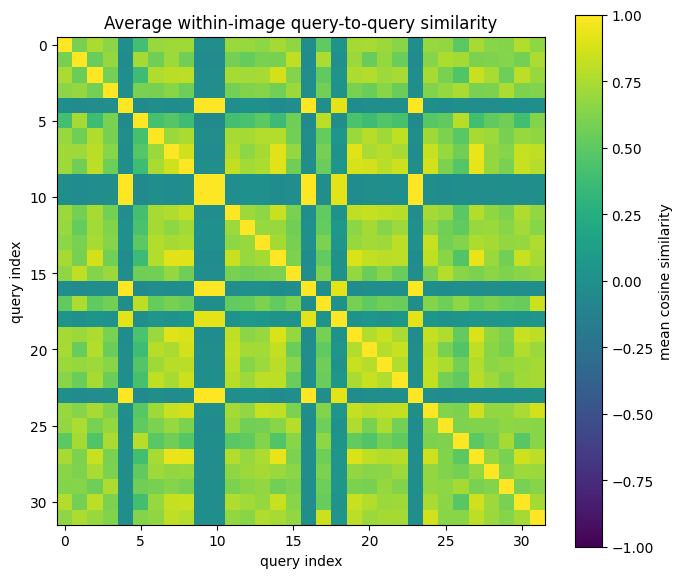

mean off-diagonal similarity 0.46607298
max off-diagonal similarity 1.0


In [9]:
import numpy as np
import matplotlib.pyplot as plt

normed = qformer_full / (np.linalg.norm(qformer_full, axis=-1, keepdims=True) + 1e-8)
sim_per_image = np.einsum("nid,njd->nij", normed, normed)
sim_avg = sim_per_image.mean(axis=0)

plt.figure(figsize=(7, 6))
plt.imshow(sim_avg, cmap="viridis", vmin=-1, vmax=1)
plt.colorbar(label="mean cosine similarity")
plt.title("Average within-image query-to-query similarity")
plt.xlabel("query index")
plt.ylabel("query index")
plt.tight_layout()
plt.savefig("query_similarity_heatmap.png", dpi=150)
plt.show()

off_diag_mask = ~np.eye(32, dtype=bool)
print("mean off-diagonal similarity", sim_avg[off_diag_mask].mean())
print("max off-diagonal similarity", sim_avg[off_diag_mask].max())

np.save("query_similarity_matrix.npy", sim_avg)

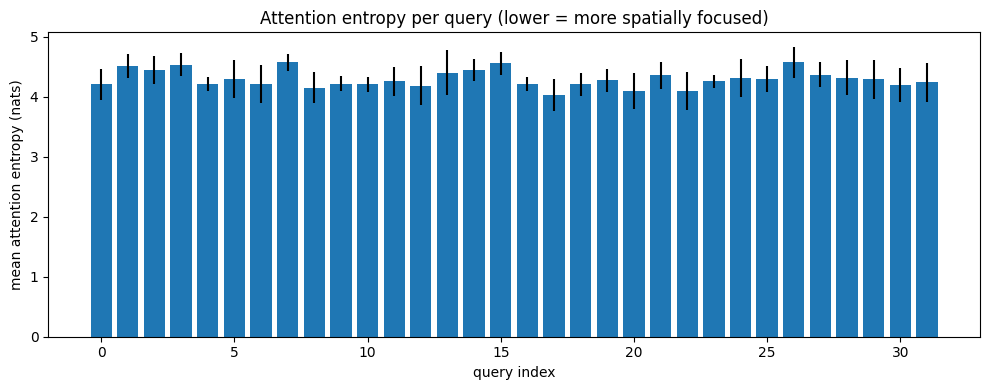

max possible entropy (uniform over 257 patches) 5.54907608489522
most focused query 17 4.0343366
most diffuse query 7 4.5767555


In [10]:
eps = 1e-12
entropy = -(attn_maps * np.log(attn_maps + eps)).sum(axis=-1)
mean_entropy_per_query = entropy.mean(axis=0)
std_entropy_per_query = entropy.std(axis=0)

plt.figure(figsize=(10, 4))
plt.bar(range(32), mean_entropy_per_query, yerr=std_entropy_per_query)
plt.xlabel("query index")
plt.ylabel("mean attention entropy (nats)")
plt.title("Attention entropy per query (lower = more spatially focused)")
plt.tight_layout()
plt.savefig("query_attention_entropy.png", dpi=150)
plt.show()

print("max possible entropy (uniform over 257 patches)", np.log(257))
print("most focused query", int(mean_entropy_per_query.argmin()), mean_entropy_per_query.min())
print("most diffuse query", int(mean_entropy_per_query.argmax()), mean_entropy_per_query.max())

np.save("query_entropy.npy", mean_entropy_per_query)

selected queries (2 most focused, 2 most diffuse): [17, 20, 26, 7]


/tmp/ipykernel_1448/266852766.py:28: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  grid_img = Image.fromarray(grid, mode="F").resize((224, 224), resample=Image.BILINEAR)


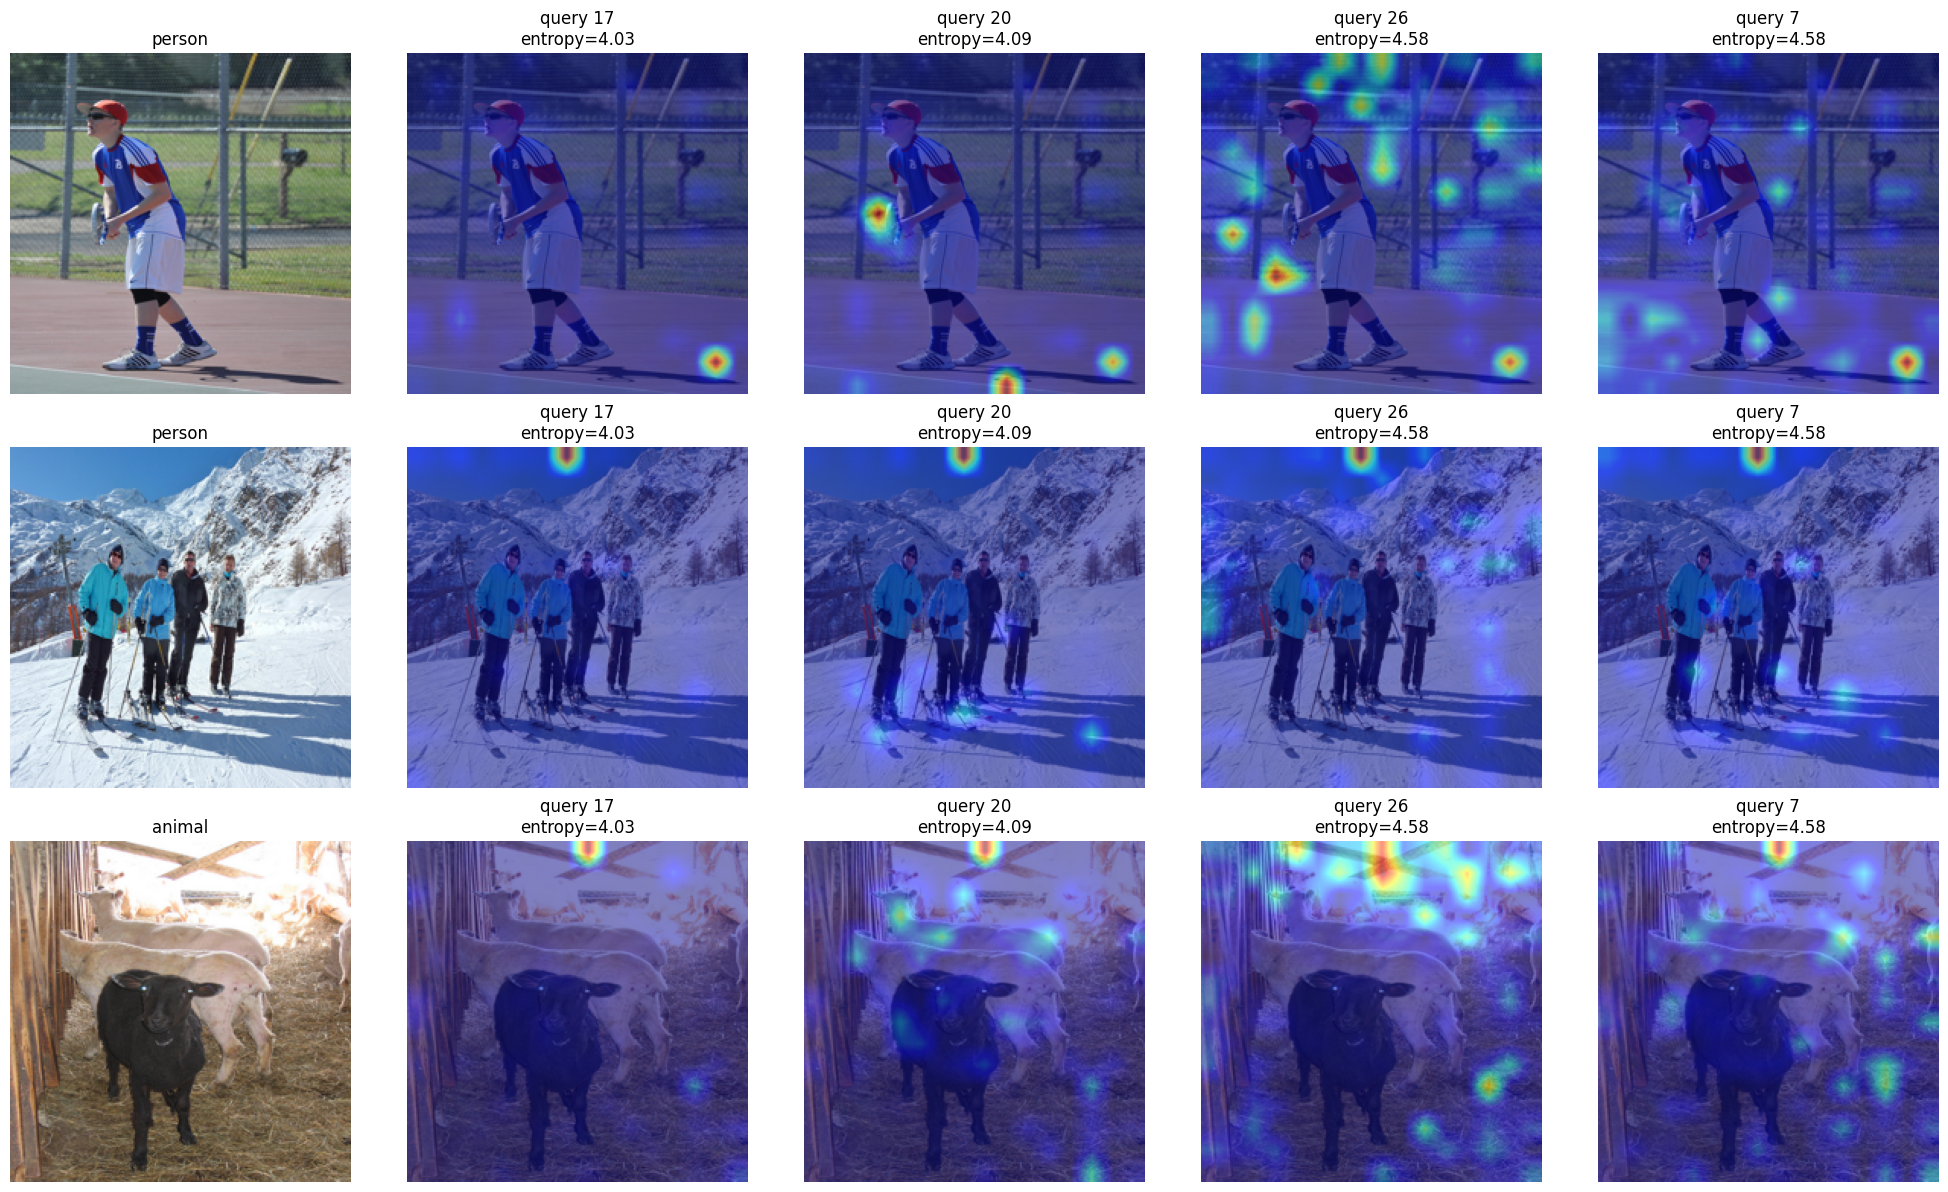

In [11]:

import os
from PIL import Image

selected_queries = [
    int(mean_entropy_per_query.argmin()),
    int(np.argsort(mean_entropy_per_query)[1]),
    int(np.argsort(mean_entropy_per_query)[-2]),
    int(mean_entropy_per_query.argmax()),
]
print("selected queries (2 most focused, 2 most diffuse):", selected_queries)

example_indices = [0, 5, 10]
fig, axes = plt.subplots(len(example_indices), len(selected_queries) + 1,
                          figsize=(4 * (len(selected_queries) + 1), 4 * len(example_indices)))

for row, img_idx in enumerate(example_indices):
    record = subset[img_idx]
    image = Image.open(os.path.join(image_dir, record["file_name"])).convert("RGB").resize((224, 224))

    ax = axes[row, 0]
    ax.imshow(image)
    ax.set_title(record["label"])
    ax.axis("off")

    for col, q in enumerate(selected_queries):
        patch_attn = attn_maps[img_idx, q, 1:]
        grid = patch_attn.reshape(16, 16).astype(np.float32)
        grid_img = Image.fromarray(grid, mode="F").resize((224, 224), resample=Image.BILINEAR)
        grid_upsampled = np.array(grid_img)
        grid_norm = (grid_upsampled - grid_upsampled.min()) / (grid_upsampled.max() - grid_upsampled.min() + 1e-8)

        ax = axes[row, col + 1]
        ax.imshow(image)
        ax.imshow(grid_norm, cmap="jet", alpha=0.5)
        ax.set_title(f"query {q}\nentropy={mean_entropy_per_query[q]:.2f}")
        ax.axis("off")

plt.tight_layout()
plt.savefig("query_attention_heatmaps.png", dpi=150)
plt.show()

  0%|          | 0/32 [00:00<?, ?it/s]

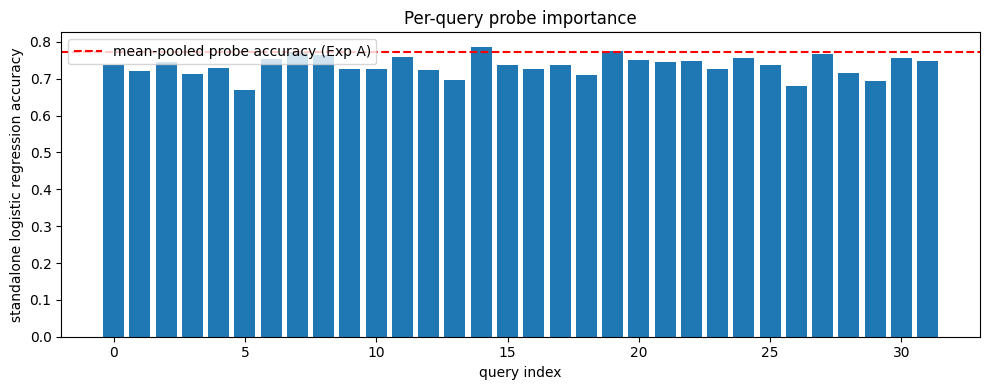

importance ranking, best to worst: [14, 19, 7, 27, 8, 11, 30, 24, 6, 20, 31, 22, 21, 2, 25, 0, 15, 17, 4, 23, 9, 10, 16, 12, 1, 28, 3, 18, 13, 29, 26, 5]
top 5 [14 19  7 27  8] [0.78673981 0.77485697 0.77236285 0.76673785 0.7648413 ]
bottom 5 [18 13 29 26  5] [0.71044867 0.69668299 0.69419867 0.68105799 0.66980603]


In [12]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from tqdm.auto import tqdm

y_b = le.transform(labels_b)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

per_query_acc = []
for q in tqdm(range(32)):
    X_q = qformer_full[:, q, :]
    pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
    scores = cross_val_score(pipe, X_q, y_b, cv=skf)
    per_query_acc.append(scores.mean())
per_query_acc = np.array(per_query_acc)

pooled_logreg_scores, _ = cv_scores(qformer_pooled, y)

plt.figure(figsize=(10, 4))
plt.bar(range(32), per_query_acc)
plt.axhline(pooled_logreg_scores.mean(), color="red", linestyle="--", label="mean-pooled probe accuracy (Exp A)")
plt.xlabel("query index")
plt.ylabel("standalone logistic regression accuracy")
plt.title("Per-query probe importance")
plt.legend()
plt.tight_layout()
plt.savefig("per_query_probe_importance.png", dpi=150)
plt.show()

query_ranking = np.argsort(-per_query_acc)
print("importance ranking, best to worst:", query_ranking.tolist())
print("top 5", query_ranking[:5], per_query_acc[query_ranking[:5]])
print("bottom 5", query_ranking[-5:], per_query_acc[query_ranking[-5:]])

np.save("per_query_acc.npy", per_query_acc)
np.save("query_ranking.npy", query_ranking)

In [13]:
mean_sim_per_query = (sim_avg.sum(axis=1) - 1) / 31
distinct_ranking = np.argsort(mean_sim_per_query)

print("most distinct queries (lowest avg similarity to the other 31):")
print(distinct_ranking[:8].tolist(), mean_sim_per_query[distinct_ranking[:8]])
print("most redundant queries (highest avg similarity to the other 31):")
print(distinct_ranking[-8:].tolist(), mean_sim_per_query[distinct_ranking[-8:]])

most distinct queries (lowest avg similarity to the other 31):
[16, 4, 23, 9, 10, 18, 5, 26] [0.14580843 0.1458096  0.14581293 0.14581527 0.14581536 0.17776604
 0.39336488 0.46344256]
most redundant queries (highest avg similarity to the other 31):
[21, 31, 14, 8, 19, 27, 24, 7] [0.568528   0.57852334 0.57898325 0.5827286  0.585884   0.58738685
 0.58751297 0.58857125]


In [14]:
query_norm_mean = np.linalg.norm(qformer_full, axis=-1).mean(axis=0)
query_norm_std = np.linalg.norm(qformer_full, axis=-1).std(axis=0)
query_variance_across_images = qformer_full.var(axis=0).mean(axis=-1)

print("suspect queries:")
for q in [16, 4, 23, 9, 10, 18, 5, 26]:
    print(f"query {q}: mean norm={query_norm_mean[q]:.3f}, norm std={query_norm_std[q]:.4f}, cross-image variance={query_variance_across_images[q]:.5f}")

print("\nall 32 queries, sorted by cross-image variance (low = barely responds to the image):")
variance_ranking = np.argsort(query_variance_across_images)
for q in variance_ranking:
    print(int(q), round(float(query_variance_across_images[q]), 5), round(float(query_norm_mean[q]), 3))

suspect queries:
query 16: mean norm=9.833, norm std=0.1318, cross-image variance=0.00073
query 4: mean norm=9.833, norm std=0.1312, cross-image variance=0.00073
query 23: mean norm=9.837, norm std=0.1343, cross-image variance=0.00074
query 9: mean norm=9.836, norm std=0.1337, cross-image variance=0.00074
query 10: mean norm=9.836, norm std=0.1333, cross-image variance=0.00074
query 18: mean norm=10.035, norm std=0.8057, cross-image variance=0.02565
query 5: mean norm=11.281, norm std=1.6167, cross-image variance=0.08790
query 26: mean norm=10.732, norm std=0.8091, cross-image variance=0.09822

all 32 queries, sorted by cross-image variance (low = barely responds to the image):
4 0.00073 9.833
16 0.00073 9.833
10 0.00074 9.836
9 0.00074 9.836
23 0.00074 9.837
18 0.02565 10.035
17 0.0751 11.524
5 0.0879 11.281
1 0.09156 10.424
26 0.09822 10.732
31 0.10118 10.689
7 0.10755 10.336
15 0.1082 10.734
27 0.11257 10.401
3 0.11457 10.843
25 0.11784 11.055
24 0.12043 10.777
19 0.12267 10.873
14 

In [15]:
print("probe accuracy for dead/semi-dead queries:")
for q in [4, 9, 10, 16, 23, 18]:
    print(f"query {q}: probe acc = {per_query_acc[q]:.3f}, cross-image variance = {query_variance_across_images[q]:.5f}")

print("\noverall per-query probe accuracy: mean", per_query_acc.mean(), "std", per_query_acc.std())

from scipy.stats import spearmanr
corr, pval = spearmanr(query_variance_across_images, per_query_acc)
print(f"\nSpearman correlation, cross-image variance vs. probe accuracy: r={corr:.3f}, p={pval:.4f}")

probe accuracy for dead/semi-dead queries:
query 4: probe acc = 0.728, cross-image variance = 0.00073
query 9: probe acc = 0.727, cross-image variance = 0.00074
query 10: probe acc = 0.727, cross-image variance = 0.00074
query 16: probe acc = 0.726, cross-image variance = 0.00073
query 23: probe acc = 0.727, cross-image variance = 0.00074
query 18: probe acc = 0.710, cross-image variance = 0.02565

overall per-query probe accuracy: mean 0.7356182650862069 std 0.02672095228017215

Spearman correlation, cross-image variance vs. probe accuracy: r=0.380, p=0.0318


## Experiment C — Query Ablation

**Question:** how many of the 32 queries are actually necessary for retrieval, and does informed
pruning (guided by each query's own standalone retrieval usefulness) preserve performance better than
naive random pruning at the same query count?

Setup: image-text retrieval on the same COCO subset used throughout, one caption per image. BLIP-2's
ITC similarity between an image and a text is the *maximum* cosine similarity across the image's 32
query embeddings against the text embedding (the paper's own scoring convention). We reuse the raw
Q-Former states extracted in Experiment B for the image side; the text side is extracted fresh here.

In [16]:
from pycocotools.coco import COCO

coco_caps = COCO("annotations/captions_val2017.json")

captions = []
for r in subset:
    ann_ids = coco_caps.getAnnIds(imgIds=r["image_id"])
    anns = coco_caps.loadAnns(ann_ids)
    captions.append(anns[0]["caption"])

print(len(captions))
print(captions[:3])

loading annotations into memory...
Done (t=0.08s)
creating index...
index created!
1599
['A man holding a tennis racquet on a tennis court.', 'A full view of a beautiful store in a town. ', 'Advertising photograph of a surf-themed birthday cake from a bakery']


In [17]:
import torch
import torch.nn.functional as F
import numpy as np
from tqdm.auto import tqdm

batch_size = 32
all_text_embeds = []

for i in tqdm(range(0, len(captions), batch_size)):
    batch_captions = captions[i:i + batch_size]
    text_inputs_b = processor(text=batch_captions, return_tensors="pt", padding=True).to(device)
    with torch.inference_mode():
        text_out_b = text_model(**text_inputs_b)
    pooled = text_out_b.text_embeds[:, 0, :]
    all_text_embeds.append(F.normalize(pooled, dim=-1).float().cpu())

text_embeds_all = torch.cat(all_text_embeds).numpy()

qformer_full_tensor = torch.from_numpy(qformer_full).to(device, torch.float16)
with torch.inference_mode():
    projected = vision_model.vision_projection(qformer_full_tensor)
    image_embeds_all = F.normalize(projected, dim=-1).float().cpu().numpy()

print("image_embeds_all", image_embeds_all.shape)
print("text_embeds_all", text_embeds_all.shape)

np.save("image_embeds_all.npy", image_embeds_all)
np.save("text_embeds_all.npy", text_embeds_all)

  0%|          | 0/50 [00:00<?, ?it/s]

image_embeds_all (1599, 32, 256)
text_embeds_all (1599, 256)


In [18]:
def recall_at_k(sim_matrix, k):
    n = sim_matrix.shape[0]
    topk = np.argsort(-sim_matrix, axis=1)[:, :k]
    correct = np.array([i in topk[i] for i in range(n)])
    return correct.mean()

sim_all = np.einsum("iqd,td->iqt", image_embeds_all, text_embeds_all)
sim_i2t = sim_all.max(axis=1)
sim_t2i = sim_i2t.T

for k in [1, 5, 10]:
    print(f"Image->Text Recall@{k}: {recall_at_k(sim_i2t, k):.3f}")
for k in [1, 5, 10]:
    print(f"Text->Image Recall@{k}: {recall_at_k(sim_t2i, k):.3f}")

print(f"\nchance-level Recall@1 for reference: {1 / sim_i2t.shape[0]:.4f}")

Image->Text Recall@1: 0.662
Image->Text Recall@5: 0.909
Image->Text Recall@10: 0.956
Text->Image Recall@1: 0.662
Text->Image Recall@5: 0.894
Text->Image Recall@10: 0.948

chance-level Recall@1 for reference: 0.0006


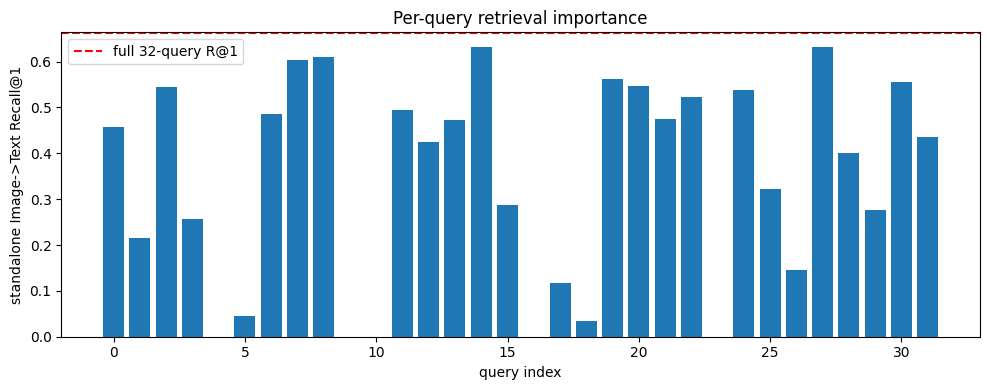

retrieval-based ranking, best to worst: [14, 27, 8, 7, 19, 30, 20, 2, 24, 22, 11, 6, 21, 13, 0, 31, 12, 28, 25, 15, 29, 3, 1, 26, 17, 5, 18, 4, 9, 10, 23, 16]
top 5 [14 27  8  7 19] [0.63227017 0.63227017 0.60913071 0.60350219 0.56285178]
bottom 5 [ 4  9 10 23 16] [0. 0. 0. 0. 0.]

dead queries (from Exp B) — does retrieval agree?
query 4: retrieval R@1 = 0.000, classification probe acc = 0.728
query 9: retrieval R@1 = 0.000, classification probe acc = 0.727
query 10: retrieval R@1 = 0.000, classification probe acc = 0.727
query 16: retrieval R@1 = 0.000, classification probe acc = 0.726
query 23: retrieval R@1 = 0.000, classification probe acc = 0.727
query 18: retrieval R@1 = 0.034, classification probe acc = 0.710

Spearman(cross-image variance, retrieval R@1): r=0.694, p=0.0000
Spearman(classification probe acc, retrieval R@1): r=0.788, p=0.0000


In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

per_query_recall1 = []
for q in range(32):
    sim_q = image_embeds_all[:, q, :] @ text_embeds_all.T
    per_query_recall1.append(recall_at_k(sim_q, 1))
per_query_recall1 = np.array(per_query_recall1)

retrieval_ranking = np.argsort(-per_query_recall1)

plt.figure(figsize=(10, 4))
plt.bar(range(32), per_query_recall1)
plt.axhline(recall_at_k(sim_i2t, 1), color="red", linestyle="--", label="full 32-query R@1")
plt.xlabel("query index")
plt.ylabel("standalone Image->Text Recall@1")
plt.title("Per-query retrieval importance")
plt.legend()
plt.tight_layout()
plt.savefig("per_query_retrieval_importance.png", dpi=150)
plt.show()

print("retrieval-based ranking, best to worst:", retrieval_ranking.tolist())
print("top 5", retrieval_ranking[:5], per_query_recall1[retrieval_ranking[:5]])
print("bottom 5", retrieval_ranking[-5:], per_query_recall1[retrieval_ranking[-5:]])

print("\ndead queries (from Exp B) — does retrieval agree?")
for q in [4, 9, 10, 16, 23, 18]:
    print(f"query {q}: retrieval R@1 = {per_query_recall1[q]:.3f}, classification probe acc = {per_query_acc[q]:.3f}")

corr_var, p_var = spearmanr(query_variance_across_images, per_query_recall1)
corr_probe, p_probe = spearmanr(per_query_acc, per_query_recall1)
print(f"\nSpearman(cross-image variance, retrieval R@1): r={corr_var:.3f}, p={p_var:.4f}")
print(f"Spearman(classification probe acc, retrieval R@1): r={corr_probe:.3f}, p={p_probe:.4f}")

np.save("per_query_recall1.npy", per_query_recall1)
np.save("retrieval_ranking.npy", retrieval_ranking)

k=32: informed R@1=0.662, random R@1=0.662 +/- 0.000
k=16: informed R@1=0.663, random R@1=0.655 +/- 0.005
k=8: informed R@1=0.664, random R@1=0.622 +/- 0.030
k=4: informed R@1=0.660, random R@1=0.538 +/- 0.142
k=2: informed R@1=0.650, random R@1=0.488 +/- 0.126
k=1: informed R@1=0.632, random R@1=0.412 +/- 0.195


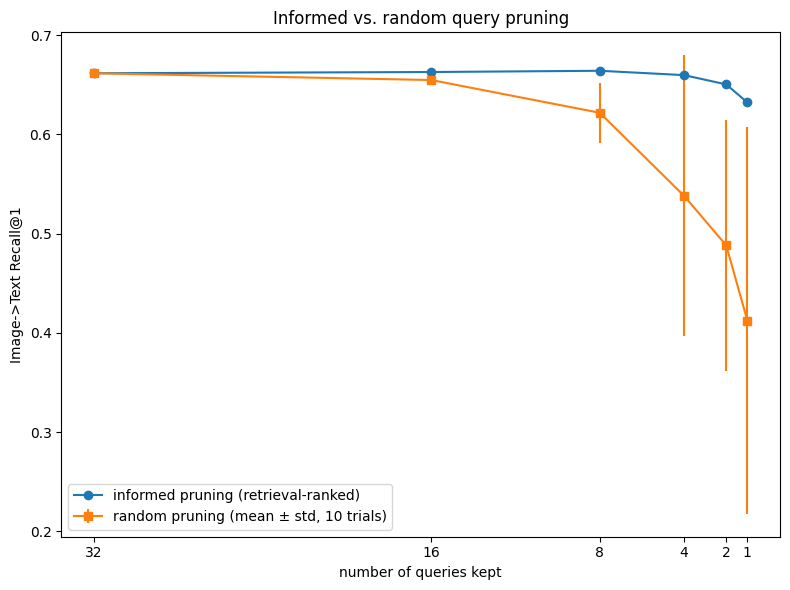

   num_queries  informed_R@1  random_R@1_mean  random_R@1_std
0           32      0.661664         0.661664        0.000000
1           16      0.662914         0.654847        0.004758
2            8      0.664165         0.621826        0.030186
3            4      0.659787         0.538086        0.141718
4            2      0.650407         0.488118        0.126429
5            1      0.632270         0.412445        0.194818


In [20]:
def recall_at_k_for_queries(image_embeds_all, text_embeds_all, query_indices, k):
    sub = image_embeds_all[:, query_indices, :]
    sim = np.einsum("iqd,td->iqt", sub, text_embeds_all).max(axis=1)
    return recall_at_k(sim, k)

query_counts = [32, 16, 8, 4, 2, 1]
n_random_trials = 10
rng = np.random.default_rng(0)

results_k, results_informed, results_random_mean, results_random_std = [], [], [], []

for num_q in query_counts:
    informed_indices = retrieval_ranking[:num_q]
    informed_r1 = recall_at_k_for_queries(image_embeds_all, text_embeds_all, informed_indices, 1)

    random_r1s = [
        recall_at_k_for_queries(image_embeds_all, text_embeds_all, rng.choice(32, size=num_q, replace=False), 1)
        for _ in range(n_random_trials)
    ]

    results_k.append(num_q)
    results_informed.append(informed_r1)
    results_random_mean.append(np.mean(random_r1s))
    results_random_std.append(np.std(random_r1s))

    print(f"k={num_q}: informed R@1={informed_r1:.3f}, random R@1={np.mean(random_r1s):.3f} +/- {np.std(random_r1s):.3f}")

plt.figure(figsize=(8, 6))
plt.errorbar(results_k, results_informed, marker="o", label="informed pruning (retrieval-ranked)")
plt.errorbar(results_k, results_random_mean, yerr=results_random_std, marker="s", label="random pruning (mean ± std, 10 trials)")
plt.xlabel("number of queries kept")
plt.ylabel("Image->Text Recall@1")
plt.title("Informed vs. random query pruning")
plt.legend()
plt.gca().invert_xaxis()
plt.xticks(query_counts)
plt.tight_layout()
plt.savefig("query_pruning_recall.png", dpi=150)
plt.show()

import pandas as pd
df = pd.DataFrame({"num_queries": results_k, "informed_R@1": results_informed,
                    "random_R@1_mean": results_random_mean, "random_R@1_std": results_random_std})
print(df)
df.to_csv("query_pruning_results.csv", index=False)

### Result

| queries kept | informed R@1 | random R@1 (mean ± std, 10 trials) |
|---|---|---|
| 32 | 0.662 | 0.662 ± 0.000 |
| 16 | 0.663 | 0.655 ± 0.005 |
| 8  | 0.664 | 0.622 ± 0.030 |
| 4  | 0.660 | 0.538 ± 0.142 |
| 2  | 0.650 | 0.488 ± 0.126 |
| 1  | 0.632 | 0.412 ± 0.195 |

Retrieval reveals sharp, unambiguous per-query differentiation that classification (Experiment A/B)
could not: the five queries with near-zero cross-image variance score **exactly 0.000** standalone
Recall@1, while the best individual query (index 14) alone reaches 0.632 — 95% of the full 32-query
ensemble's performance. Both earlier signals now correlate strongly with retrieval usefulness
(Spearman r=0.694 with cross-image variance, r=0.788 with classification probe accuracy, both
p<0.0001), confirming they were detecting a real effect the coarse classification task had simply
compressed into a narrow, hard-to-see range.

Informed pruning — guided by each query's own standalone retrieval performance — preserves the full
32-query baseline almost exactly down to 4 queries (0.660 vs. 0.662) and retains 95% of it with a
*single* query. Random pruning degrades steadily and, critically, its variance grows sharply as k
shrinks (±0.142 at k=4, ±0.195 at k=1) — a random draw risks landing on a dead query and collapsing
performance, a risk informed selection eliminates entirely.

## Experiment D -- From Ablation to Caption Selection

Experiment C measured whether restricting to the top query still finds the
*correct* caption somewhere in the top-K. This experiment asks a related but
stricter question: even when the informed single-query model doesn't retrieve the
exact ground-truth caption, **how similar is what it picks to what the full
32-query ensemble would have picked?** That's a harder test -- it doesn't get
credit just for matching ground truth some fraction of the time, it has to
actually agree with the full model's own choice.

This stays entirely on `blip2-itm-vit-g` -- no second checkpoint, no text
generation, no new model download. `blip2-itm-vit-g` has no language model
attached, so there's no such thing as free-form "generation" here anyway; what we
can do is ask which caption it *selects* from the candidate pool, which is exactly
the operation Experiment C's Recall@K already performs -- we're just reading out
the actual selected caption instead of a yes/no about whether it was correct.

For every image, we get three "selected" captions: using the full 32-query
max-similarity (BLIP-2's own scoring convention), using only the single best
query from Experiment C's ranking, and using one random query per image as a
control. We compare the informed and random selections against the full-model
selection using the caption embeddings already computed in Experiment C
(`text_embeds_all`) -- no re-embedding needed. That gives two similarity
distributions across images (`sim_top`, `sim_rand`), compared with KL divergence.

Because this is pure matrix algebra on embeddings we already have, there's no
reason to subsample -- we run it over the full 1,599-image dataset, so unlike a
generation-based version of this experiment, there's no small-sample noise
caveat to carry around.

In [21]:
# Three "which caption gets picked" regimes, all within blip2-itm-vit-g, reusing
# image_embeds_all / text_embeds_all / retrieval_ranking from Experiment C.
rng = np.random.default_rng(2)
n = image_embeds_all.shape[0]
best_query = int(retrieval_ranking[0])
random_queries = rng.integers(0, 32, size=n)  # one random query index per image

idx_full = sim_i2t.argmax(axis=1)  # full 32-query max-similarity selection (Experiment C's own convention)

sim_top_matrix = image_embeds_all[:, best_query, :] @ text_embeds_all.T
idx_top = sim_top_matrix.argmax(axis=1)

sim_rand_matrix = np.einsum("id,td->it", image_embeds_all[np.arange(n), random_queries, :], text_embeds_all)
idx_rand = sim_rand_matrix.argmax(axis=1)

print("best query (from Experiment C's retrieval ranking):", best_query)
print("fraction of images where the top-query selection exactly matches the full-model selection:  ", (idx_top == idx_full).mean())
print("fraction of images where a random-query selection exactly matches the full-model selection: ", (idx_rand == idx_full).mean())

print("\nsample selections:")
for i in rng.choice(n, size=5, replace=False):
    print(f"image {i} (ground-truth caption: {captions[i]!r})")
    print(f"  full-model pick  : {captions[idx_full[i]]!r}")
    print(f"  top-query pick   : {captions[idx_top[i]]!r}")
    print(f"  random-query pick: {captions[idx_rand[i]]!r}")


best query (from Experiment C's retrieval ranking): 14
fraction of images where the top-query selection exactly matches the full-model selection:   0.8142589118198874
fraction of images where a random-query selection exactly matches the full-model selection:  0.425891181988743

sample selections:
image 1130 (ground-truth caption: 'A street filled with lots of traffic next to tall buildings.')
  full-model pick  : 'A street filled with lots of traffic next to tall buildings.'
  top-query pick   : 'A street filled with buses and a white van.'
  random-query pick: 'A view of a street with some trees around it.'
image 253 (ground-truth caption: 'A nearly empty plate containing broccoli and brown sauce.')
  full-model pick  : 'A plate of broccoli and meat on a table.'
  top-query pick   : 'A white bowl filled with meat, vegetables and broth.'
  random-query pick: 'A table topped with a plate of food next to eating utensils.'
image 1440 (ground-truth caption: 'A plate holding a grilled chees

In [22]:
# How similar is the *selected caption text* to what the full model picked?
# text_embeds_all rows are already unit-normalized (Experiment C), so a dot
# product is exactly cosine similarity -- no re-embedding needed.
sim_top = (text_embeds_all[idx_full] * text_embeds_all[idx_top]).sum(axis=1)
sim_rand = (text_embeds_all[idx_full] * text_embeds_all[idx_rand]).sum(axis=1)

print(f"mean similarity, full vs. top-query (q{best_query}) selection: {sim_top.mean():.3f} +/- {sim_top.std():.3f}")
print(f"mean similarity, full vs. random-query selection:      {sim_rand.mean():.3f} +/- {sim_rand.std():.3f}")

np.save("expD_sim_top.npy", sim_top)
np.save("expD_sim_rand.npy", sim_rand)


mean similarity, full vs. top-query (q14) selection: 0.968 +/- 0.076
mean similarity, full vs. random-query selection:      0.857 +/- 0.151


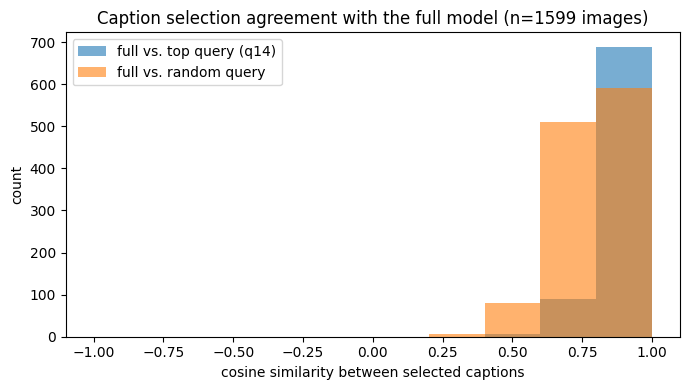

KL(top || random) = 0.3321 nats
KL(random || top) = 0.5126 nats


In [23]:
import matplotlib.pyplot as plt
from scipy.stats import entropy

bins = np.linspace(-1, 1, 11)  # cosine similarity always lives in [-1, 1]
p_top, _ = np.histogram(sim_top, bins=bins)
p_rand, _ = np.histogram(sim_rand, bins=bins)

eps = 1e-6  # avoids log(0) / division by zero in bins neither distribution landed in
p_top = p_top.astype(float) + eps
p_rand = p_rand.astype(float) + eps
p_top /= p_top.sum()
p_rand /= p_rand.sum()

# KL divergence is NOT symmetric -- the two directions answer different questions.
# KL(top || random): how surprised you'd be seeing the "top query" similarity scores
#   if you had assumed they behaved like the "random query" baseline.
# KL(random || top): the reverse question.
kl_top_vs_rand = entropy(p_top, p_rand)
kl_rand_vs_top = entropy(p_rand, p_top)

plt.figure(figsize=(7, 4))
plt.hist(sim_top, bins=bins, alpha=0.6, label=f"full vs. top query (q{best_query})")
plt.hist(sim_rand, bins=bins, alpha=0.6, label="full vs. random query")
plt.xlabel("cosine similarity between selected captions")
plt.ylabel("count")
plt.title(f"Caption selection agreement with the full model (n={len(sim_top)} images)")
plt.legend()
plt.tight_layout()
plt.savefig("caption_selection_similarity_distributions.png", dpi=150)
plt.show()

print(f"KL(top || random) = {kl_top_vs_rand:.4f} nats")
print(f"KL(random || top) = {kl_rand_vs_top:.4f} nats")


## Experiment E -- Generalization Beyond One Sample

Two real gaps in Experiments C/D, raised independently and both correct:

1. **The query ranking was found and evaluated on the same 1,599 images.**
   Reporting query 14's Recall@1 on the exact data used to crown it as the winner
   is the retrieval-metrics equivalent of tuning on your test set. We need to know
   whether it still wins on images it never touched.
2. **"Top-k" so far means the k individually-best queries, assumed to combine well.**
   That's a greedy assumption, not a proven one -- it's possible some other
   combination of k queries (not the k individual leaders) works better together,
   if the leaders overlap heavily in what they encode.

This experiment addresses both, plus checks whether the finding survives moving to
an entirely different dataset (Flickr30k), which is exactly the zero-shot-transfer
protocol the BLIP-2 paper itself uses (Table 5: COCO-finetuned, evaluated
zero-shot on Flickr30k).

**Four parts:**
- **E1-E2**: build a second, disjoint ~1,599-image COCO batch ("holdout") from
  images never used in Experiments A-D, and extract its embeddings the same way.
  No class-balancing needed this time -- retrieval never used the labels.
- **E3**: evaluate the *discovery-set* query ranking's top-k (k = 1, 2, 4, 8) on
  the holdout batch, against random-k on the same holdout batch. This is the
  actual generalization test.
- **E4 (split-half reliability)**: independently rank all 32 queries *using only
  the holdout set*, and compare that ranking to the discovery-set ranking via
  Spearman correlation. If "query 14 is best" is a real property of this
  checkpoint's Q-Former rather than noise from one particular sample, the two
  independently-derived rankings should largely agree.
- **E5-E6 (brute force, k = 1/2/4 only)**: exhaustively search all C(32,k)
  combinations on the discovery set to find the *true* best k-query combo, check
  whether it matches the greedy top-k, then evaluate both on holdout. C(32,8) is
  10.5 million combinations, well past what's practical to brute-force here, so
  k = 8 stays greedy-vs-random only (from E3).
- **E7 (cross-dataset transfer)**: repeat E3's test on a Flickr30k sample instead
  of a second COCO batch.

**Honesty note on E7**: I wrote it against `nlphuji/flickr30k` on the Hugging Face
Hub, which is a commonly-used public mirror, but I couldn't execute it myself to
confirm the exact dataset id and field names still match what's below as of when
you run this. If it errors on load, search "flickr30k" on huggingface.co/datasets
and swap in whatever public version is current -- the rest of the cell only
assumes each row has an image field and a caption (or list of captions).

In [24]:
# E1: build a disjoint holdout batch from COCO val2017 images never used in
# Experiments A-D. No class-balancing -- retrieval doesn't use the `label` field
# at all, that was only ever needed for the classification probes in A/B.
seen_ids = {r["image_id"] for r in subset}
remaining_records = [r for r in records if r["image_id"] not in seen_ids]
print(f"images available for holdout (never used above): {len(remaining_records)}")

random.seed(1)  # different seed from the discovery subset's seed(0)
random.shuffle(remaining_records)
holdout_target = min(1599, len(remaining_records))
subset_holdout = remaining_records[:holdout_target]

print(f"holdout batch size: {len(subset_holdout)}")
print("holdout label distribution (informational only, unused for retrieval):", Counter(r["label"] for r in subset_holdout))


images available for holdout (never used above): 3353
holdout batch size: 1599
holdout label distribution (informational only, unused for retrieval): Counter({'person': 682, 'vehicle': 295, 'animal': 260, 'furniture': 235, 'food': 55, 'indoor': 31, 'outdoor': 28, 'appliance': 13})


In [25]:
# E2: extract Q-Former + caption embeddings for the holdout batch, identical
# pipeline to Experiments B/C, just pointed at subset_holdout instead of subset.
batch_size = 16
all_qformer_holdout = []

for i in tqdm(range(0, len(subset_holdout), batch_size)):
    batch = subset_holdout[i:i + batch_size]
    images = [Image.open(os.path.join(image_dir, r["file_name"])).convert("RGB") for r in batch]
    inputs = processor(images=images, return_tensors="pt").to(device, torch.float16)
    with torch.inference_mode():
        patch_embeds = vision_model.vision_model(pixel_values=inputs.pixel_values).last_hidden_state
        query_tokens = vision_model.query_tokens.expand(patch_embeds.shape[0], -1, -1)
        qformer_out = vision_model.qformer(query_embeds=query_tokens, encoder_hidden_states=patch_embeds)
        qformer_hidden = qformer_out.last_hidden_state
    all_qformer_holdout.append(qformer_hidden.float().cpu())

qformer_holdout = torch.cat(all_qformer_holdout).numpy()

with torch.inference_mode():
    qformer_holdout_tensor = torch.from_numpy(qformer_holdout).to(device, torch.float16)
    projected_holdout = vision_model.vision_projection(qformer_holdout_tensor)
    image_embeds_holdout = F.normalize(projected_holdout, dim=-1).float().cpu().numpy()

# first COCO caption per image, same convention as Experiment C
captions_holdout = []
for r in subset_holdout:
    ann_ids = coco_caps.getAnnIds(imgIds=r["image_id"])
    anns = coco_caps.loadAnns(ann_ids)
    captions_holdout.append(anns[0]["caption"])

all_text_embeds_holdout = []
for i in tqdm(range(0, len(captions_holdout), batch_size)):
    batch_captions = captions_holdout[i:i + batch_size]
    text_inputs_b = processor(text=batch_captions, return_tensors="pt", padding=True).to(device)
    with torch.inference_mode():
        text_out_b = text_model(**text_inputs_b)
    pooled = text_out_b.text_embeds[:, 0, :]
    all_text_embeds_holdout.append(F.normalize(pooled, dim=-1).float().cpu())

text_embeds_holdout = torch.cat(all_text_embeds_holdout).numpy()

print("image_embeds_holdout", image_embeds_holdout.shape)
print("text_embeds_holdout", text_embeds_holdout.shape)

np.save("image_embeds_holdout.npy", image_embeds_holdout)
np.save("text_embeds_holdout.npy", text_embeds_holdout)


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

image_embeds_holdout (1599, 32, 256)
text_embeds_holdout (1599, 256)


In [26]:
# E3: does the DISCOVERY-set query ranking (Experiment C) still win on a fresh,
# disjoint COCO batch it was never used to select from?
sim_all_holdout = np.einsum("iqd,td->iqt", image_embeds_holdout, text_embeds_holdout)
sim_i2t_holdout = sim_all_holdout.max(axis=1)
print(f"Holdout full 32-query Image->Text Recall@1: {recall_at_k(sim_i2t_holdout, 1):.3f}")
print(f"(discovery-set full 32-query Recall@1 was:  {recall_at_k(sim_i2t, 1):.3f}, for comparison)\n")

query_counts = [32, 16, 8, 4, 2, 1]
n_random_trials = 10
rng = np.random.default_rng(0)

print("evaluating the discovery-set ranking's top-k on the HOLDOUT set:")
for num_q in query_counts:
    informed_indices = retrieval_ranking[:num_q]  # selected using ONLY the discovery set
    informed_r1 = recall_at_k_for_queries(image_embeds_holdout, text_embeds_holdout, informed_indices, 1)
    random_r1s = [
        recall_at_k_for_queries(image_embeds_holdout, text_embeds_holdout, rng.choice(32, size=num_q, replace=False), 1)
        for _ in range(n_random_trials)
    ]
    print(f"k={num_q}: informed (discovery-ranked) R@1={informed_r1:.3f}, random R@1={np.mean(random_r1s):.3f} +/- {np.std(random_r1s):.3f}")


Holdout full 32-query Image->Text Recall@1: 0.633
(discovery-set full 32-query Recall@1 was:  0.662, for comparison)

evaluating the discovery-set ranking's top-k on the HOLDOUT set:
k=32: informed (discovery-ranked) R@1=0.633, random R@1=0.633 +/- 0.000
k=16: informed (discovery-ranked) R@1=0.635, random R@1=0.629 +/- 0.006
k=8: informed (discovery-ranked) R@1=0.635, random R@1=0.600 +/- 0.027
k=4: informed (discovery-ranked) R@1=0.632, random R@1=0.512 +/- 0.137
k=2: informed (discovery-ranked) R@1=0.635, random R@1=0.451 +/- 0.122
k=1: informed (discovery-ranked) R@1=0.609, random R@1=0.395 +/- 0.189


In [27]:
# E4: split-half reliability -- rank all 32 queries using ONLY the holdout set,
# independently of Experiment C's discovery-set ranking, then compare the two.
# If "query 14 matters" is a real property of this checkpoint rather than noise
# from one particular 1,599-image sample, the two independent rankings should
# largely agree.
per_query_recall1_holdout = []
for q in range(32):
    sim_q = image_embeds_holdout[:, q, :] @ text_embeds_holdout.T
    per_query_recall1_holdout.append(recall_at_k(sim_q, 1))
per_query_recall1_holdout = np.array(per_query_recall1_holdout)

retrieval_ranking_holdout = np.argsort(-per_query_recall1_holdout)

print("discovery-set ranking, best to worst:", retrieval_ranking.tolist())
print("holdout-set ranking, best to worst:  ", retrieval_ranking_holdout.tolist())
print("\ntop 5 on discovery:", retrieval_ranking[:5].tolist())
print("top 5 on holdout:   ", retrieval_ranking_holdout[:5].tolist())

from scipy.stats import spearmanr
corr, pval = spearmanr(per_query_recall1, per_query_recall1_holdout)
print(f"\nSpearman correlation between the two independently-derived 32-query rankings: r={corr:.3f}, p={pval:.4f}")

overlap = len(set(retrieval_ranking[:5].tolist()) & set(retrieval_ranking_holdout[:5].tolist()))
print(f"overlap in the two top-5 lists: {overlap}/5 queries")

np.save("per_query_recall1_holdout.npy", per_query_recall1_holdout)
np.save("retrieval_ranking_holdout.npy", retrieval_ranking_holdout)


discovery-set ranking, best to worst: [14, 27, 8, 7, 19, 30, 20, 2, 24, 22, 11, 6, 21, 13, 0, 31, 12, 28, 25, 15, 29, 3, 1, 26, 17, 5, 18, 4, 9, 10, 23, 16]
holdout-set ranking, best to worst:   [27, 14, 8, 7, 19, 30, 20, 22, 24, 11, 2, 21, 6, 13, 0, 12, 31, 28, 25, 15, 29, 3, 1, 26, 17, 5, 18, 4, 9, 10, 23, 16]

top 5 on discovery: [14, 27, 8, 7, 19]
top 5 on holdout:    [27, 14, 8, 7, 19]

Spearman correlation between the two independently-derived 32-query rankings: r=0.996, p=0.0000
overlap in the two top-5 lists: 5/5 queries


In [28]:
# E5: is the greedy top-k combination (k individually-best queries) actually the
# best possible k-query COMBINATION, or could some other combo do better together?
# Brute-force only k = 1, 2, 4 here -- C(32,8) is 10.5 million combinations, well
# past what's practical without a smarter search. This cell only touches the
# DISCOVERY set; holdout is untouched until the next cell.


from itertools import combinations

n_disc = image_embeds_all.shape[0]
per_query_sim_disc = [image_embeds_all[:, q, :] @ text_embeds_all.T for q in range(32)]


def recall1_from_sim(sim_matrix):
    return (sim_matrix.argmax(axis=1) == np.arange(sim_matrix.shape[0])).mean()


def combo_recall1(query_indices, per_query_sim=per_query_sim_disc):
    combined = per_query_sim[query_indices[0]]
    for q in query_indices[1:]:
        combined = np.maximum(combined, per_query_sim[q])
    return recall1_from_sim(combined)


brute_force_best = {}
for k in [1, 2, 4]:
    best_r1, best_combo = -1.0, None
    for combo in tqdm(list(combinations(range(32), k)), desc=f"k={k}"):
        r1 = combo_recall1(combo)
        if r1 > best_r1:
            best_r1, best_combo = r1, combo

    greedy_combo = tuple(retrieval_ranking[:k].tolist())
    greedy_r1 = combo_recall1(greedy_combo)
    brute_force_best[k] = best_combo

    match = "MATCH" if set(best_combo) == set(greedy_combo) else "DIFFERENT combo"
    print(f"k={k}: brute-force best {best_combo} -> R@1={best_r1:.3f}  |  greedy top-{k} {greedy_combo} -> R@1={greedy_r1:.3f}  |  {match}")


k=1:   0%|          | 0/32 [00:00<?, ?it/s]

k=1: brute-force best (14,) -> R@1=0.632  |  greedy top-1 (14,) -> R@1=0.632  |  MATCH


k=2:   0%|          | 0/496 [00:00<?, ?it/s]

k=2: brute-force best (14, 27) -> R@1=0.650  |  greedy top-2 (14, 27) -> R@1=0.650  |  MATCH


k=4:   0%|          | 0/35960 [00:00<?, ?it/s]

k=4: brute-force best (2, 19, 22, 27) -> R@1=0.664  |  greedy top-4 (14, 27, 8, 7) -> R@1=0.660  |  DIFFERENT combo


In [29]:
# E6: whichever combo (greedy vs. brute-force-optimal) was found on the
# discovery set, does either generalize better to the untouched holdout set?
for k in [1, 2, 4]:
    greedy_combo = list(retrieval_ranking[:k])
    bf_combo = list(brute_force_best[k])

    greedy_holdout_r1 = recall_at_k_for_queries(image_embeds_holdout, text_embeds_holdout, greedy_combo, 1)
    bf_holdout_r1 = recall_at_k_for_queries(image_embeds_holdout, text_embeds_holdout, bf_combo, 1)

    print(f"k={k}: greedy {tuple(greedy_combo)} -> holdout R@1={greedy_holdout_r1:.3f}  |  "
          f"brute-force-optimal {tuple(bf_combo)} -> holdout R@1={bf_holdout_r1:.3f}")


k=1: greedy (np.int64(14),) -> holdout R@1=0.609  |  brute-force-optimal (14,) -> holdout R@1=0.609
k=2: greedy (np.int64(14), np.int64(27)) -> holdout R@1=0.635  |  brute-force-optimal (14, 27) -> holdout R@1=0.635
k=4: greedy (np.int64(14), np.int64(27), np.int64(8), np.int64(7)) -> holdout R@1=0.632  |  brute-force-optimal (2, 19, 22, 27) -> holdout R@1=0.630


In [32]:
# E7: cross-dataset transfer -- does the discovery-set ranking still mean
# anything on a completely different image distribution and caption style?

!pip install -q "datasets>=2.19"

from datasets import load_dataset

flickr_records = None

for name, split in [
    ("nlphuji/flickr_1k_test_image_text_retrieval", "test"),
    ("nlphuji/flickr30k", "test"),
]:
    try:
        ds = load_dataset(name, split=split, revision="refs/convert/parquet")
        cols = ds.column_names
        print(f"loaded '{name}' via refs/convert/parquet, columns: {cols}")

        image_col = next((c for c in cols if c.lower() in ("image", "img", "jpg", "photo")), None)
        caption_col = next((c for c in cols if any(k in c.lower() for k in ("cap", "sentence", "text"))), None)
        if image_col is None or caption_col is None:
            print(f"  couldn't identify image/caption columns from {cols}, trying next candidate")
            continue

        n = min(1599, len(ds))
        rng = np.random.default_rng(3)
        idx = rng.choice(len(ds), size=n, replace=False)
        flickr_records = []
        for i in idx:
            row = ds[int(i)]
            cap = row[caption_col]
            cap = cap[0] if isinstance(cap, list) else cap
            flickr_records.append({"image": row[image_col].convert("RGB"), "caption": cap})
        print(f"using '{name}': {len(flickr_records)} pairs")
        break
    except Exception as e:
        print(f"'{name}' failed: {type(e).__name__}: {e}")

if flickr_records is None:
    print("\nFlickr30k dead end -- falling back to Wikipedia image-text pairs (WIT)")
    wit = load_dataset("wikimedia/wit_base", split="train", streaming=True)
    flickr_records = []
    for row in wit:
        cap = row.get("caption_reference_description") or row.get("caption_alt_text_description")
        if not cap or not isinstance(cap, str) or len(cap.split()) < 3:
            continue
        try:
            flickr_records.append({"image": row["image"].convert("RGB"), "caption": cap})
        except Exception:
            continue
        if len(flickr_records) >= 1599:
            break
    print(f"using wikimedia/wit_base: {len(flickr_records)} pairs")

if not flickr_records:
    raise RuntimeError("Nothing loaded from any candidate -- see the printed errors above.")

print("example pair:", flickr_records[0]["caption"])

TEST/test/0000.parquet: reconstructing file:   0%|          |  0.00B /  142MB            

TEST/test/0000.parquet: downloading bytes:           |  0.00B            

Generating test split: 0 examples [00:00, ? examples/s]

loaded 'nlphuji/flickr_1k_test_image_text_retrieval' via refs/convert/parquet, columns: ['image', 'caption', 'sentids', 'imgid', 'split', 'filename', 'tokens', 'sentid']
using 'nlphuji/flickr_1k_test_image_text_retrieval': 1000 pairs
example pair: A man in a black, white, and red uniform is holding yellow ski poles and racing or preparing to race.


In [33]:

flickr_images = [r["image"] for r in flickr_records]
flickr_captions = [r["caption"] for r in flickr_records]

batch_size = 16
all_qformer_flickr = []

for i in tqdm(range(0, len(flickr_images), batch_size)):
    images = flickr_images[i:i + batch_size]
    inputs = processor(images=images, return_tensors="pt").to(device, torch.float16)
    with torch.inference_mode():
        patch_embeds = vision_model.vision_model(pixel_values=inputs.pixel_values).last_hidden_state
        query_tokens = vision_model.query_tokens.expand(patch_embeds.shape[0], -1, -1)
        qformer_out = vision_model.qformer(query_embeds=query_tokens, encoder_hidden_states=patch_embeds)
        qformer_hidden = qformer_out.last_hidden_state
    all_qformer_flickr.append(qformer_hidden.float().cpu())

qformer_flickr = torch.cat(all_qformer_flickr).numpy()

with torch.inference_mode():
    qformer_flickr_tensor = torch.from_numpy(qformer_flickr).to(device, torch.float16)
    projected_flickr = vision_model.vision_projection(qformer_flickr_tensor)
    image_embeds_flickr = F.normalize(projected_flickr, dim=-1).float().cpu().numpy()

all_text_embeds_flickr = []
for i in tqdm(range(0, len(flickr_captions), batch_size)):
    batch_captions = flickr_captions[i:i + batch_size]
    text_inputs_b = processor(text=batch_captions, return_tensors="pt", padding=True).to(device)
    with torch.inference_mode():
        text_out_b = text_model(**text_inputs_b)
    pooled = text_out_b.text_embeds[:, 0, :]
    all_text_embeds_flickr.append(F.normalize(pooled, dim=-1).float().cpu())

text_embeds_flickr = torch.cat(all_text_embeds_flickr).numpy()

print("image_embeds_flickr", image_embeds_flickr.shape)
print("text_embeds_flickr", text_embeds_flickr.shape)

np.save("image_embeds_flickr.npy", image_embeds_flickr)
np.save("text_embeds_flickr.npy", text_embeds_flickr)

  0%|          | 0/63 [00:00<?, ?it/s]

  0%|          | 0/63 [00:00<?, ?it/s]

image_embeds_flickr (1000, 32, 256)
text_embeds_flickr (1000, 256)


In [34]:
# Same generalization test as E3, now on Flickr30k instead of a second COCO batch.
sim_all_flickr = np.einsum("iqd,td->iqt", image_embeds_flickr, text_embeds_flickr)
sim_i2t_flickr = sim_all_flickr.max(axis=1)
print(f"Flickr30k full 32-query Image->Text Recall@1: {recall_at_k(sim_i2t_flickr, 1):.3f}\n")

rng = np.random.default_rng(0)
print("evaluating the COCO-discovery-set ranking's top-k on FLICKR30K:")
for num_q in [32, 16, 8, 4, 2, 1]:
    informed_indices = retrieval_ranking[:num_q]
    informed_r1 = recall_at_k_for_queries(image_embeds_flickr, text_embeds_flickr, informed_indices, 1)
    random_r1s = [
        recall_at_k_for_queries(image_embeds_flickr, text_embeds_flickr, rng.choice(32, size=num_q, replace=False), 1)
        for _ in range(10)
    ]
    print(f"k={num_q}: informed (COCO-ranked) R@1={informed_r1:.3f}, random R@1={np.mean(random_r1s):.3f} +/- {np.std(random_r1s):.3f}")


Flickr30k full 32-query Image->Text Recall@1: 0.877

evaluating the COCO-discovery-set ranking's top-k on FLICKR30K:
k=32: informed (COCO-ranked) R@1=0.877, random R@1=0.877 +/- 0.000
k=16: informed (COCO-ranked) R@1=0.878, random R@1=0.859 +/- 0.007
k=8: informed (COCO-ranked) R@1=0.875, random R@1=0.820 +/- 0.034
k=4: informed (COCO-ranked) R@1=0.857, random R@1=0.710 +/- 0.151
k=2: informed (COCO-ranked) R@1=0.854, random R@1=0.636 +/- 0.134
k=1: informed (COCO-ranked) R@1=0.823, random R@1=0.555 +/- 0.245
